# Analyzing the Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import ARA_model
from collections import defaultdict, Counter
import ast
import nltk

import indices

In [2]:
dataset_train = pd.read_json("data/training_data.jsonl", lines=True)
annotations_train = pd.read_json("data/annotations_train.jsonl", lines=True)

dataset_dev = pd.read_json("data/development_data.jsonl", lines=True)
annotations_dev = pd.read_json("data/annotations_dev.jsonl", lines=True)

dataset_eval = pd.read_json("data/evaluation_data.jsonl", lines=True)
annotations_eval = pd.read_json("data/annotations_eval.jsonl", lines=True)

In [5]:
def add_annotations(dataset, annotations):
    # Merge the dataset with the annotations on the 'id' column
    merged_df = pd.merge(dataset, annotations, on="id", how="inner")
    return merged_df

dataset_train = add_annotations(dataset_train, annotations_train)
dataset_dev = add_annotations(dataset_dev, annotations_dev)
dataset_eval = add_annotations(dataset_eval, annotations_eval)

### Size of the Splits

In [6]:
print(len(dataset_train), "train annotations")
print(len(dataset_dev), "dev annotations")
print(len(dataset_eval), "eval annotations")

960 train annotations
267 dev annotations
407 eval annotations


## Basic Metrics

In [7]:
def average_sentence_length(df):
    '''
    average sentence length in words
    '''

    total_length = 0
    for sentence in df['target']:
        total_length += len(sentence.split())
    return total_length / len(df)

def average_word_length(df):
    '''
    average word length in syllables
    '''

    syllable_tokenizer = nltk.tokenize.SyllableTokenizer(lang = "en") # syllable tokenizer only works for English, but as we only want the number of syllables, the results are good enough for German
    
    total_length = 0
    total_words = 0
    for sentence in df['target']:
        words = sentence.split()
        total_words += len(words)
        for word in words:
            total_length += len(syllable_tokenizer.tokenize(word))
    return total_length / total_words if total_words > 0 else 0

print(f"Average sentence length in train set: {average_sentence_length(dataset_train):.2f} words")
print(f"Average sentence length in dev set: {average_sentence_length(dataset_dev):.2f} words")
print(f"Average sentence length in eval set: {average_sentence_length(dataset_eval):.2f} words")

print(f"Average word length in train set: {average_word_length(dataset_train):.2f} syllables")
print(f"Average word length in dev set: {average_word_length(dataset_dev):.2f} syllables")
print(f"Average word length in eval set: {average_word_length(dataset_eval):.2f} syllables")

Average sentence length in train set: 16.92 words
Average sentence length in dev set: 17.50 words
Average sentence length in eval set: 17.32 words
Average word length in train set: 2.28 syllables
Average word length in dev set: 2.32 syllables
Average word length in eval set: 2.28 syllables


/home/benja/anaconda3/envs/MA/lib/python3.11/site-packages/nltk/tokenize/sonority_sequencing.py:102: UserWarning: Character not defined in sonority_hierarchy, assigning as vowel: 'ö'
  warnings.warn(
/home/benja/anaconda3/envs/MA/lib/python3.11/site-packages/nltk/tokenize/sonority_sequencing.py:102: UserWarning: Character not defined in sonority_hierarchy, assigning as vowel: 'ä'
  warnings.warn(
/home/benja/anaconda3/envs/MA/lib/python3.11/site-packages/nltk/tokenize/sonority_sequencing.py:102: UserWarning: Character not defined in sonority_hierarchy, assigning as vowel: 'ü'
  warnings.warn(
/home/benja/anaconda3/envs/MA/lib/python3.11/site-packages/nltk/tokenize/sonority_sequencing.py:102: UserWarning: Character not defined in sonority_hierarchy, assigning as vowel: 'ß'
  warnings.warn(
/home/benja/anaconda3/envs/MA/lib/python3.11/site-packages/nltk/tokenize/sonority_sequencing.py:102: UserWarning: Character not defined in sonority_hierarchy, assigning as vowel: '„'
  warnings.warn(


## Distribution over the Years

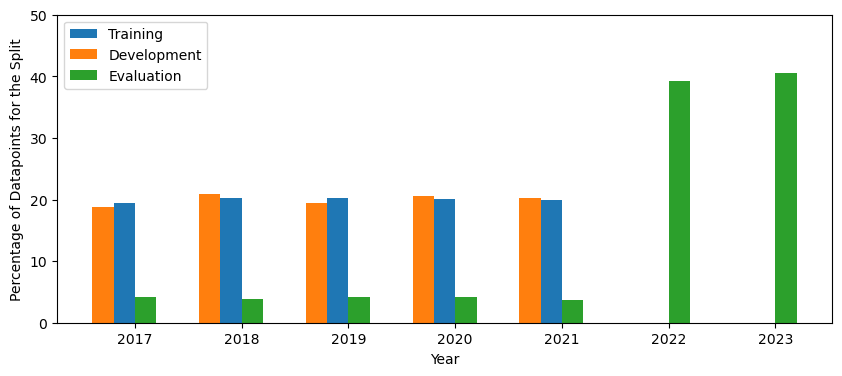

In [8]:
train_year_counts = dataset_train['year'].value_counts(normalize=True).sort_index() * 100
dev_year_counts = dataset_dev['year'].value_counts(normalize=True).sort_index() * 100 # normalize = true for percentages
eval_year_counts = dataset_eval['year'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(10, 4))
plt.bar(train_year_counts.index - 0.1, train_year_counts.values, width=0.2, label='Training')
plt.bar(dev_year_counts.index - 0.3, dev_year_counts.values, width=0.2, label='Development')
plt.bar(eval_year_counts.index + 0.1, eval_year_counts.values, width=0.2, label='Evaluation')
plt.ylim([0, 50])

plt.xlabel('Year')
plt.ylabel('Percentage of Datapoints for the Split')
plt.legend()
plt.savefig('figures/understandability_years.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Calculating the Majority Vote

In [11]:
def majority_vote(data):

    # Find all elements with maximum frequency
    count = Counter(data)
    max_count = max(list(count.values()))
    modes = [k for k, v in count.items() if v == max_count]

    # If there is more than one mode, return the mean of the modes
    if len(modes) > 1:
        return np.mean(modes)
    else:
        return float(modes[0])

In [12]:
# Calculcate the majority vote for understandability
dataset_train['understandability_maj_vote'] = dataset_train['understandability'].apply(majority_vote)
dataset_dev['understandability_maj_vote'] = dataset_dev['understandability'].apply(majority_vote)
dataset_eval['understandability_maj_vote'] = dataset_eval['understandability'].apply(majority_vote)


def bin_df(df):
# group by majority vote (binning to the lower class)
    df["understandability_maj_vote_binned"] = df["understandability_maj_vote"].apply(lambda x: 1 if x < 2 else 2 if x < 3 else 3 if x < 4 else 4)
    return df

dataset_train = bin_df(dataset_train)
dataset_dev = bin_df(dataset_dev)
dataset_eval = bin_df(dataset_eval)

In [14]:
# Mean of the mean of the understandability ratings
print("Mean mean train:", round(dataset_train['understandability'].apply(np.mean).mean(), 3))
print("Mean mean dev:", round(dataset_dev['understandability'].apply(np.mean).mean(), 3))
print("Mean mean eval:", round(dataset_eval['understandability'].apply(np.mean).mean(), 3))

# Mean of the majority vote of understandability ratings
print("Mean maj_vote train:", round(dataset_train['understandability_maj_vote'].mean(), 3))
print("Mean maj_vote dev:", round(dataset_dev['understandability_maj_vote'].mean(), 3))
print("Mean maj_vote eval:", round(dataset_eval['understandability_maj_vote'].mean(), 3))

# Mean of the stddev of understandability ratings
print("Mean stddev train:", round(dataset_train['understandability'].apply(np.std).mean(), 3))
print("Mean stddev dev:", round(dataset_dev['understandability'].apply(np.std).mean(), 3))
print("Mean stddev eval:", round(dataset_eval['understandability'].apply(np.std).mean(), 3))

Mean mean train: 3.515
Mean mean dev: 3.2
Mean mean eval: 3.526
Mean maj_vote train: 3.695
Mean maj_vote dev: 3.431
Mean maj_vote eval: 3.709
Mean stddev train: 0.505
Mean stddev dev: 0.691
Mean stddev eval: 0.501


### Class Imbalance

In [15]:
def brackets_and_percentages(series:pd.Series, latex_able = False):
    """
    Convert each cell to a string with leading "(" and trainling ")%"
    """
    if latex_able:
        return series.apply(lambda x: f"({round(x, 2)}\\%)" if pd.notna(x) else "")
    else:
        return series.apply(lambda x: f"({round(x, 2)}%)" if pd.notna(x) else "")


def class_imbalance(train, dev, eval):


    train_counts = train["understandability_maj_vote"].value_counts().sort_index()
    dev_counts = dev["understandability_maj_vote"].value_counts().sort_index()
    eval_counts = eval["understandability_maj_vote"].value_counts().sort_index()

    train_ratio = round(train_counts / train_counts.sum(), 4) * 100    
    train_ratio = brackets_and_percentages(train_ratio, latex_able=True)

    dev_ratio = round(dev_counts / dev_counts.sum(), 4) * 100
    dev_ratio = brackets_and_percentages(dev_ratio, latex_able=True)

    eval_ratio = round(eval_counts / eval_counts.sum(), 4) * 100
    eval_ratio = brackets_and_percentages(eval_ratio, latex_able=True)


    df = pd.DataFrame({
        "Train": train_counts,
        "Train_ratio": train_ratio,

        "Dev": dev_counts,
        "Dev_ratio": dev_ratio,

        "Eval": eval_counts,
        "Eval_ratio": eval_ratio
    })
    

    return df.T


    

class_imbalances = class_imbalance(dataset_train, dataset_dev, dataset_eval)

# class_imbalances.to_csv("figures/understandability_class_imbalances.csv")

class_imbalances

understandability_maj_vote,1.0,1.5,2.0,2.5,3.0,3.5,4.0
Train,5,1,21,19,167,76,671
Train_ratio,(0.52\%),(0.1\%),(2.19\%),(1.98\%),(17.4\%),(7.92\%),(69.9\%)
Dev,NaN,NaN,11.0,14.0,90.0,38.0,114.0
Dev_ratio,NaN,NaN,(4.12\%),(5.24\%),(33.71\%),(14.23\%),(42.7\%)
Eval,NaN,NaN,7.0,4.0,81.0,35.0,280.0
Eval_ratio,NaN,NaN,(1.72\%),(0.98\%),(19.9\%),(8.6\%),(68.8\%)


## Calculating Inter Annotator Agreement using Raw Agreement

In [18]:
def x_agree(annotations:list) -> int:
    """
    Check how many annotators agree on the most common rating.
    """

    # Count occurrences of each rating
    counts = pd.Series(annotations).value_counts()

    if counts.max() < 2:
        return 0
    else:
        return counts.max()    


def mode_agreement(df):

    num_rows_with_2 = df[df['understandability'].apply(lambda x: len(x) >= 2)].shape[0]
    num_rows_with_3 = df[df['understandability'].apply(lambda x: len(x) >= 3)].shape[0]
    num_rows_with_4 = df[df['understandability'].apply(lambda x: len(x) >= 4)].shape[0]
    num_rows_with_5 = df[df['understandability'].apply(lambda x: len(x) >= 5)].shape[0]
    num_rows_with_6 = df[df['understandability'].apply(lambda x: len(x) >= 6)].shape[0]

    df["agreement"] = df['understandability'].apply(x_agree)

    agree_2 = df[df["agreement"] >= 2].shape[0]
    agree_3 = df[df["agreement"] >= 3].shape[0]
    agree_4 = df[df["agreement"] >= 4].shape[0]
    agree_5 = df[df["agreement"] >= 5].shape[0]
    agree_6 = df[df["agreement"] >= 6].shape[0]

    ratio_2 = round(agree_2 / num_rows_with_2, 4) if num_rows_with_2 != 0 else 0
    ratio_3 = round(agree_3 / num_rows_with_3, 4) if num_rows_with_3 != 0 else 0
    ratio_4 = round(agree_4 / num_rows_with_4, 4) if num_rows_with_4 != 0 else 0
    ratio_5 = round(agree_5 / num_rows_with_5, 4) if num_rows_with_5 != 0 else 0
    ratio_6 = round(agree_6 / num_rows_with_6, 4) if num_rows_with_6 != 0 else 0


    
    print("At least 2 annotators agree on the same rating in", agree_2, "out of", num_rows_with_2, "rows (", ratio_2 * 100, "%).")

    if num_rows_with_3 != 0:
        print("At least 3 annotators agree on the same rating in", agree_3, "out of", num_rows_with_3, "rows (", ratio_3 * 100, "%).")
    print("At least 4 annotators agree on the same rating in", agree_4, "out of", num_rows_with_4, "rows (", ratio_4 * 100, "%).")
    print("At least 5 annotators agree on the same rating in", agree_5, "out of", num_rows_with_5, "rows (", ratio_5 * 100, "%).")
    print("At least 6 annotators agree on the same rating in", agree_6, "out of", num_rows_with_6, "rows (", ratio_6 * 100, "%).")

    df["mode_agreement"] = df["agreement"] / df['understandability'].apply(len)
    print("Average Mode Agreement:", round(df["mode_agreement"].mean(), 3))

print("\ntrain")
mode_agreement(dataset_train)
print("\ndev")
mode_agreement(dataset_dev)
print("\neval")
mode_agreement(dataset_eval)


train
At least 2 annotators agree on the same rating in 960 out of 960 rows ( 100.0 %).
At least 3 annotators agree on the same rating in 833 out of 960 rows ( 86.77 %).
At least 4 annotators agree on the same rating in 473 out of 960 rows ( 49.27 %).
At least 5 annotators agree on the same rating in 162 out of 939 rows ( 17.25 %).
At least 6 annotators agree on the same rating in 5 out of 43 rows ( 11.63 %).
Average Mode Agreement: 0.703

dev
At least 2 annotators agree on the same rating in 267 out of 267 rows ( 100.0 %).
At least 3 annotators agree on the same rating in 193 out of 267 rows ( 72.28 %).
At least 4 annotators agree on the same rating in 71 out of 267 rows ( 26.590000000000003 %).
At least 5 annotators agree on the same rating in 9 out of 267 rows ( 3.37 %).
At least 6 annotators agree on the same rating in 0 out of 0 rows ( 0 %).
Average Mode Agreement: 0.604

eval
At least 2 annotators agree on the same rating in 407 out of 407 rows ( 100.0 %).
At least 3 annotators 